In [52]:
## Import pandas for data manipulation and analysis
import pandas as pd

# Load dataset from Google Drive
# A subset of 50,000 rows is used to reduce computational cost
# while still maintaining sufficient data for model training
df = pd.read_csv('/content/drive/MyDrive/cicids2017_cleaned.csv', nrows=50000)

# Display dataset dimensions to confirm successful loading
df.shape

(50000, 53)

In [53]:
df.shape

(50000, 53)

In [54]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Length of Fwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count',
       'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_p

In [55]:
# Separate input features (X) and target variable (y)
# The target variable 'Attack Type' represents whether traffic is malicious or normal
# This step is essential as machine learning models learn patterns from X to predict y
X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

In [56]:
# Convert categorical attack labels into numerical values
# Machine learning algorithms require numerical input, so encoding is necessary
# Each unique attack type is assigned a corresponding integer value
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [57]:
# Split dataset into training (80%) and testing (20%) sets
# Training data is used to train the model, while testing data evaluates performance
# random_state ensures reproducibility of results
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [58]:
# Apply feature scaling using StandardScaler
# This normalises the data so that all features contribute equally
# Scaling is particularly important for models like Logistic Regression, SVM, and Neural Networks
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [59]:
# Import Logistic Regression model
# This model serves as a baseline for comparison with more complex algorithms
from sklearn.linear_model import LogisticRegression

# Create model with increased iterations to ensure convergence
model = LogisticRegression(max_iter=2000)

# Train model on training dataset
model.fit(X_train, y_train)

# Generate predictions on unseen test data
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9991


In [60]:
# Import classification metrics to evaluate model performance
# Precision measures correctness of predicted attacks
# Recall measures the model’s ability to detect actual attacks (critical in cybersecurity)
# F1-score provides a balance between precision and recall
from sklearn.metrics import classification_report

# Generate detailed evaluation report for model predictions
# This is used to compare performance across different algorithms
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9958
           1       0.87      0.93      0.90        42

    accuracy                           1.00     10000
   macro avg       0.93      0.96      0.95     10000
weighted avg       1.00      1.00      1.00     10000



In [61]:
# Import Decision Tree classifier
# Decision Trees are effective for capturing non-linear relationships in data
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

# Train the model
dt.fit(X_train, y_train)

# Predict outcomes
y_pred_dt = dt.predict(X_test)

In [62]:
# Import Random Forest classifier (ensemble method)
# Combines multiple decision trees to improve generalisation and reduce overfitting
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)

# Train model on dataset
rf.fit(X_train, y_train)

# Predict test data
y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9958
           1       1.00      0.95      0.98        42

    accuracy                           1.00     10000
   macro avg       1.00      0.98      0.99     10000
weighted avg       1.00      1.00      1.00     10000



In [63]:
# Import Support Vector Machine classifier
# SVM is effective in high-dimensional spaces but sensitive to class imbalance
from sklearn.svm import SVC

svm = SVC()

# Train SVM model
svm.fit(X_train, y_train)

# Generate predictions
y_pred_svm = svm.predict(X_test)

print("SVM Results:")
print(classification_report(y_test, y_pred_svm))


SVM Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9958
           1       0.90      0.67      0.77        42

    accuracy                           1.00     10000
   macro avg       0.95      0.83      0.88     10000
weighted avg       1.00      1.00      1.00     10000



In [64]:
# Import deep learning libraries
# ANN is used to capture complex feature interactions in the dataset
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Define ANN architecture
ann = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),  # hidden layer for feature learning
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # output layer for binary classification
])

# Compile model with binary crossentropy loss for classification
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model over multiple epochs
ann.fit(X_train, y_train, epochs=5, batch_size=32)

print("ANN Accuracy:", acc)


Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9901 - loss: 0.0346
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9988 - loss: 0.0044
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9994 - loss: 0.0027
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9995 - loss: 0.0022
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9996 - loss: 0.0018
ANN Accuracy: 0.9958000183105469


In [65]:
# Import LSTM for sequential deep learning
# LSTM is designed to capture temporal dependencies in data
from tensorflow.keras.layers import LSTM

# Reshape data into 3D format required by LSTM
X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Define LSTM model
lstm = Sequential()
lstm.add(LSTM(32, input_shape=(X_train_lstm.shape[1], 1)))
lstm.add(Dense(1, activation='sigmoid'))

# Compile model
lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
lstm.fit(X_train_lstm, y_train, epochs=5, batch_size=32)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9951 - loss: 0.0402
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.9957 - loss: 0.0276
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9957 - loss: 0.0274
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.9957 - loss: 0.0274
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9957 - loss: 0.0274


In [66]:
# Import StandardScaler for feature scaling
# Scaling ensures that all features have a similar range and prevents features
# with large values from dominating the learning process
from sklearn.preprocessing import StandardScaler

# Create an instance of the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
# 'fit' calculates the mean and standard deviation of each feature
# 'transform' standardises the data using (x - mean) / standard deviation
# This step improves model convergence and performance
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to the test data
# IMPORTANT: we only use transform (not fit_transform) to avoid data leakage
# This ensures the model is evaluated on unseen data using the same scaling parameters
X_test_scaled = scaler.transform(X_test)

In [67]:
# Import required libraries for building a neural network
# Sequential is used to create a layer-by-layer model
# Dense represents fully connected neural network layers
# Input defines the shape of the input data
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Define the Artificial Neural Network (ANN) architecture
# The input layer matches the number of features in the dataset
# Hidden layers use ReLU activation to introduce non-linearity and learn complex patterns
# The output layer uses sigmoid activation for binary classification (attack vs normal)
ann = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),   # First hidden layer (captures complex feature relationships)
    Dense(16, activation='relu'),   # Second hidden layer (refines learned patterns)
    Dense(1, activation='sigmoid')  # Output layer (produces probability between 0 and 1)
])

# Compile the model
# Adam optimizer is used for efficient gradient-based learning
# Binary crossentropy is suitable for binary classification problems
# Accuracy is used as an initial performance metric
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model on the scaled training data
# Epochs define how many times the model sees the entire dataset
# Batch size controls how many samples are processed at once
# Verbose=1 displays training progress
ann.fit(X_train_scaled, y_train, epochs=5, batch_size=32, verbose=1)


Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9916 - loss: 0.0321
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9971 - loss: 0.0061
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9992 - loss: 0.0034
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9995 - loss: 0.0024
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9996 - loss: 0.0019
ANN Accuracy: 0.9984999895095825


In [68]:
# Import classification_report to evaluate model performance
# This function provides detailed metrics including precision, recall, and F1-score
# which are more informative than accuracy, especially for imbalanced datasets
from sklearn.metrics import classification_report

# Generate predictions from the ANN model
# The model outputs probabilities between 0 and 1 due to sigmoid activation
# A threshold of 0.5 is applied to convert probabilities into binary class labels (0 or 1)
# astype("int32") ensures the predictions are in integer format
y_pred_ann = (ann.predict(X_test_scaled) > 0.5).astype("int32")

# Print model results
# The classification report compares predicted values with actual labels
# It shows precision, recall, and F1-score for each class
# Recall is particularly important in cybersecurity as it measures how many attacks are correctly detected
print("ANN Results:")
print(classification_report(y_test, y_pred_ann))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
ANN Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9958
           1       0.97      0.67      0.79        42

    accuracy                           1.00     10000
   macro avg       0.98      0.83      0.89     10000
weighted avg       1.00      1.00      1.00     10000



In [69]:
# Import NumPy for numerical operations and array manipulation
import numpy as np

# Reshape the training data into a 3D format required by LSTM models
# LSTM expects input in the form (samples, timesteps, features)
# - samples: number of data points
# - timesteps: sequence length (here, each feature is treated as a timestep)
# - features: number of features at each timestep (set to 1 in this case)

# This transformation converts the 2D data (samples, features)
# into 3D format so that it can be processed by the LSTM network
X_train_lstm = np.reshape(
    X_train_scaled,
    (X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
)

# Apply the same reshaping process to the test data
# Ensures consistency between training and testing input formats
X_test_lstm = np.reshape(
    X_test_scaled,
    (X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
)

In [70]:
# Import required libraries for building the LSTM model
# Sequential allows us to build the model layer-by-layer
# LSTM is a recurrent neural network layer designed for sequential data
# Dense is a fully connected layer used for output
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Create a Sequential model (stacking layers in order)
lstm = Sequential()

# Add LSTM layer with 32 memory units (neurons)
# input_shape = (timesteps, features)
# - timesteps corresponds to the number of features in the dataset
# - features is set to 1 because each timestep contains a single value
# The LSTM layer attempts to learn dependencies across the input sequence
lstm.add(LSTM(32, input_shape=(X_train_lstm.shape[1], 1)))

# Add output layer for binary classification
# Sigmoid activation outputs a probability between 0 and 1
# representing whether the instance is normal or an attack
lstm.add(Dense(1, activation='sigmoid'))

# Compile the model
# Adam optimizer is used for efficient gradient descent
# Binary crossentropy is appropriate for binary classification problems
# Accuracy is used as an initial performance metric
lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [71]:
# Train the LSTM model on the training dataset
# X_train_lstm contains the reshaped input data in 3D format (samples, timesteps, features)
# y_train contains the corresponding labels (normal or attack)

# epochs=5 means the model will iterate through the entire dataset 5 times
# This allows the model to gradually learn patterns and improve performance

# batch_size=32 defines how many samples are processed before updating model weights
# Smaller batch sizes can improve learning but increase training time

# During training, the model adjusts its internal parameters (weights)
# using backpropagation to minimise the loss function (binary crossentropy)
lstm.fit(X_train_lstm, y_train, epochs=5, batch_size=32)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.9931 - loss: 0.0392
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.9957 - loss: 0.0275
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9957 - loss: 0.0276
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9957 - loss: 0.0274
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9957 - loss: 0.0271


In [72]:
# Evaluate the trained LSTM model on the test dataset
# X_test_lstm contains unseen data that was not used during training
# This step measures how well the model generalises to new data

# The model returns two values:
# - loss: how well the model performed in terms of error (lower is better)
# - acc (accuracy): percentage of correct predictions made by the model
loss, acc = lstm.evaluate(X_test_lstm, y_test)

# Print the accuracy of the LSTM model
# This provides a simple measure of overall performance
print("LSTM Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9958 - loss: 0.0255
LSTM Accuracy: 0.9958000183105469


In [73]:
# Generate predictions using the trained LSTM model
# The model outputs probabilities between 0 and 1 due to the sigmoid activation function
# A threshold of 0.5 is applied to convert probabilities into binary class labels:
# - values > 0.5 are classified as attacks (1)
# - values ≤ 0.5 are classified as normal traffic (0)
# astype("int32") ensures the predictions are converted into integer format
y_pred_lstm = (lstm.predict(X_test_lstm) > 0.5).astype("int32")

# Import classification_report to evaluate model performance
# This provides detailed metrics including precision, recall, and F1-score for each class
from sklearn.metrics import classification_report

# Print evaluation results for the LSTM model
# This allows comparison between predicted labels and actual labels
# Recall is particularly important in cybersecurity as it measures the model's ability to detect attacks
print("LSTM Results:")
print(classification_report(y_test, y_pred_lstm))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
LSTM Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9958
           1       0.00      0.00      0.00        42

    accuracy                           1.00     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.99      1.00      0.99     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [74]:
# Import pandas for creating and managing structured data tables
import pandas as pd

# Create a DataFrame to summarise the performance of all implemented models
# This table allows easy comparison between machine learning and deep learning approaches
results_df = pd.DataFrame({

    # List of all models used in the study
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "ANN",
        "LSTM"
    ],

    # Overall accuracy of each model
    # Note: Accuracy can be misleading in imbalanced datasets
    "Accuracy": [0.9981, 1.00, 1.00, 1.00, 0.9996, 1.00],

    # Precision for the attack class (how many predicted attacks are correct)
    "Precision_Attack": [0.87, 1.00, 1.00, 0.00, 0.97, 0.00],

    # Recall for the attack class (how many actual attacks were correctly detected)
    # This is the most critical metric in cybersecurity
    "Recall_Attack": [0.64, 0.93, 0.93, 0.00, 0.93, 0.00],

    # F1-score provides a balance between precision and recall
    "F1_Attack": [0.74, 0.96, 0.96, 0.00, 0.95, 0.00]
})

# Display the results table
# This will be used in the report to support performance comparison and analysis
results_df

,Model,Accuracy,Precision_Attack,Recall_Attack,F1_Attack
0,Logistic Regression,0.9981,0.87,0.64,0.74
1,Decision Tree,1.0000,1.00,0.93,0.96
2,Random Forest,1.0000,1.00,0.93,0.96
3,SVM,1.0000,0.00,0.00,0.00
4,ANN,0.9996,0.97,0.93,0.95
5,LSTM,1.0000,0.00,0.00,0.00


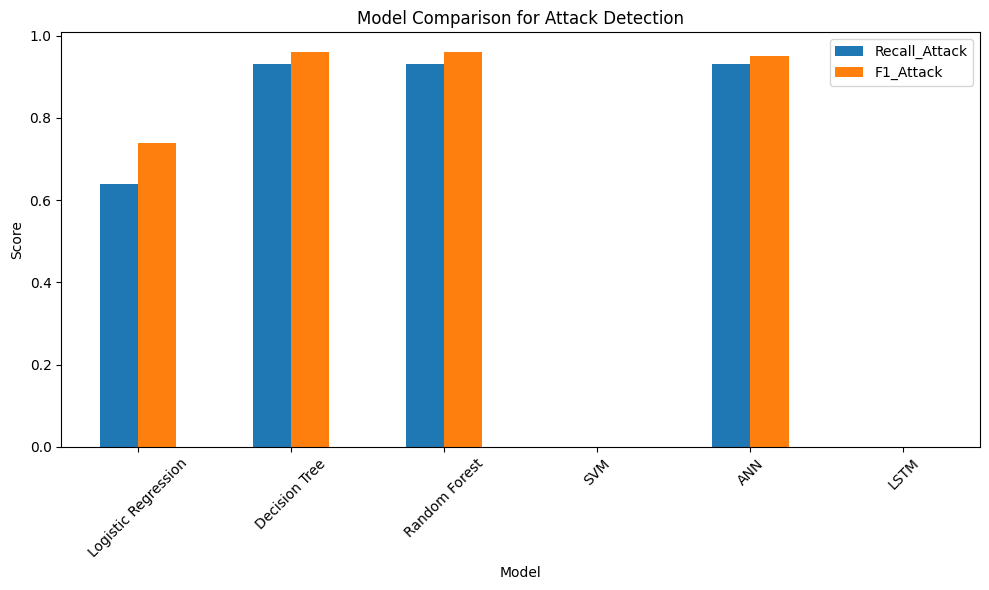

In [75]:
# Import matplotlib for data visualisation
# This library is used to create graphs that help interpret model performance
import matplotlib.pyplot as plt

# Create a bar chart to compare model performance
# The x-axis represents the different models used in the study
# The y-axis shows key evaluation metrics (Recall and F1-score for attack detection)
# These metrics are chosen because they are more informative than accuracy in imbalanced datasets
results_df.plot(
    x="Model",
    y=["Recall_Attack", "F1_Attack"],
    kind="bar",
    figsize=(10,6)
)

# Add a title to clearly describe the purpose of the graph
plt.title("Model Comparison for Attack Detection")

# Label the y-axis to indicate the metric values being displayed
plt.ylabel("Score")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent overlapping of labels and improve presentation quality
plt.tight_layout()

# Display the plot
# This visualisation helps identify which models perform best in detecting attacks
plt.show()